# 01d · PDBbind v2020 Dataset Viewer

Browse the PDBbind v2020 refined set used for the affinity-regression probe: index summary, pK + split distributions, and a 3D viewer for a chosen pocket–ligand pair.

Sources: HF `photonmz/pdbbindpp-2020` (structures) + THGLab `LP-PDBbind` (leak-proof splits + pK metadata).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

PDBBIND_DIR = Path("..") / "voxbind" / "dataset" / "data" / "pdbbind"
INDEX_CSV   = PDBBIND_DIR / "index.csv"
STRUCT_DIR  = PDBBIND_DIR / "structures" / "pbpp-2020"

ELEM_COLORS = {
    "C": "#808080", "N": "#3498db", "O": "#e74c3c", "S": "#f1c40f",
    "F": "#2ecc71", "Cl": "#27ae60", "Br": "#8e44ad", "P": "#e67e22",
    "I": "#34495e", "H": "white",
}

print(f"PDBBIND_DIR : {PDBBIND_DIR.resolve()}")
print(f"INDEX_CSV   : {INDEX_CSV.exists()=}")
print(f"STRUCT_DIR  : {STRUCT_DIR.exists()=}")

PDBBIND_DIR : /home/shpark/prj-denovo/VoxBind/voxbind/dataset/data/pdbbind
INDEX_CSV   : INDEX_CSV.exists()=True
STRUCT_DIR  : STRUCT_DIR.exists()=True


## 1. Dataset summary

Index rows                 : 19,443
On-disk (has_struct=True)  : 5,316
Categories (on-disk)       : {'refined': 5050, 'core': 266}
new_split (on-disk)        : {'train': 2999, 'test': 1439, 'val': 626, nan: 252}
pK range                   : [2.00, 11.92]
pK mean ± std              : 6.39 ± 1.95
Covalent complexes         : 0
CL1 / CL2 / CL3 (cleanest) : 4,386 / 4,384 / 4,386


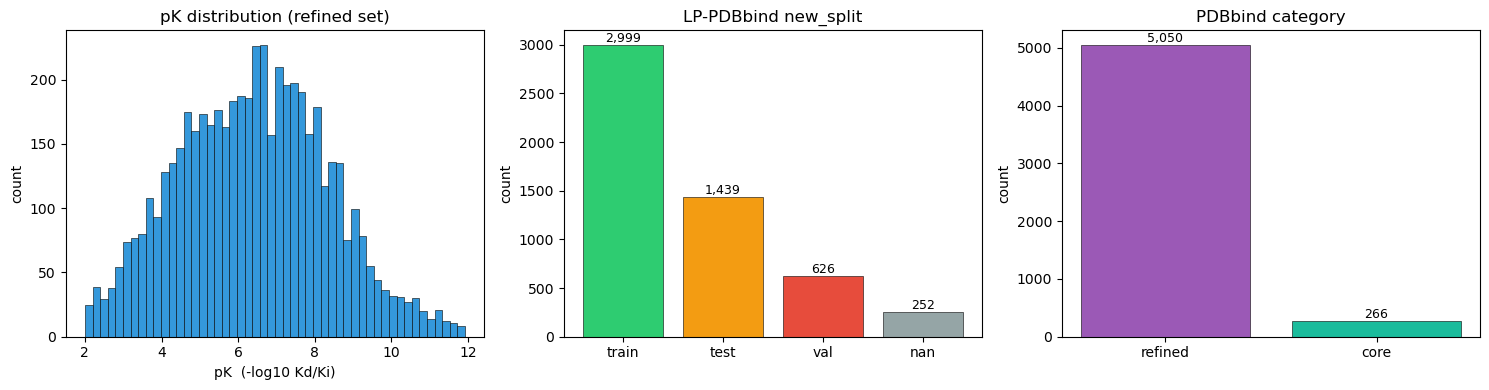

In [2]:
df = pd.read_csv(INDEX_CSV)
df_struct = df[df.has_struct].copy()

print(f"Index rows                 : {len(df):,}")
print(f"On-disk (has_struct=True)  : {len(df_struct):,}")
print(f"Categories (on-disk)       : {df_struct['category'].value_counts().to_dict()}")
print(f"new_split (on-disk)        : {df_struct['new_split'].value_counts(dropna=False).to_dict()}")
print(f"pK range                   : [{df_struct['pK'].min():.2f}, {df_struct['pK'].max():.2f}]")
print(f"pK mean ± std              : {df_struct['pK'].mean():.2f} ± {df_struct['pK'].std():.2f}")
print(f"Covalent complexes         : {df_struct['covalent'].sum():,}")
print(f"CL1 / CL2 / CL3 (cleanest) : {df_struct['CL1'].sum():,} / {df_struct['CL2'].sum():,} / {df_struct['CL3'].sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# pK histogram
axes[0].hist(df_struct['pK'].dropna(), bins=50,
             color='#3498db', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('pK  (-log10 Kd/Ki)')
axes[0].set_ylabel('count')
axes[0].set_title('pK distribution (refined set)')

# new_split bars
split_counts = df_struct['new_split'].value_counts(dropna=False)
split_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
axes[1].bar(split_counts.index.astype(str), split_counts.values,
            color=split_colors[:len(split_counts)], edgecolor='black', linewidth=0.4)
for i, v in enumerate(split_counts.values):
    axes[1].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
axes[1].set_title('LP-PDBbind new_split')
axes[1].set_ylabel('count')

# category bars
cat_counts = df_struct['category'].value_counts()
axes[2].bar(cat_counts.index, cat_counts.values,
            color=['#9b59b6', '#1abc9c', '#7f8c8d'][:len(cat_counts)],
            edgecolor='black', linewidth=0.4)
for i, v in enumerate(cat_counts.values):
    axes[2].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
axes[2].set_title('PDBbind category')
axes[2].set_ylabel('count')

fig.tight_layout()
plt.show()

## 2. Select a complex by PDB ID

Sets `row`, `poc_coords/poc_elements`, and `lig_coords/lig_elements` to the matching complex.

In [3]:
TARGET_PDB_ID = "10gs"   # 4-letter PDB code (lowercase preferred)

def load_pdb_atoms(path):
    """Parse ATOM/HETATM lines from a PDB file → (coords, elements)."""
    coords, elements = [], []
    with open(path) as f:
        for line in f:
            if line.startswith(("ATOM  ", "HETATM")):
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                el = line[76:78].strip().capitalize()
                if not el:
                    el = ''.join(c for c in line[12:16] if c.isalpha())[:1].upper()
                coords.append([x, y, z])
                elements.append(el)
    return np.array(coords), elements

def load_sdf_atoms(path):
    """Parse the atom block of an SDF V2000 → (coords, elements)."""
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[3][:3])
    coords, elements = [], []
    for i in range(n_atoms):
        line = lines[4 + i]
        x = float(line[0:10])
        y = float(line[10:20])
        z = float(line[20:30])
        el = line[31:34].strip()
        coords.append([x, y, z])
        elements.append(el)
    return np.array(coords), elements

pid = TARGET_PDB_ID.lower()
row = df[df['pdb_id'] == pid]
if row.empty:
    raise ValueError(f"{TARGET_PDB_ID!r} not in index.csv")
row = row.iloc[0]
if not row.has_struct:
    raise ValueError(
        f"{TARGET_PDB_ID!r} is in the LP index but not on disk "
        f"(category={row['category']}). The refined-only zip doesn't include the general set."
    )

complex_dir = STRUCT_DIR / pid
pocket_pdb  = complex_dir / f"{pid}_pocket.pdb"
ligand_sdf  = complex_dir / f"{pid}_ligand.sdf"

poc_coords, poc_elements = load_pdb_atoms(pocket_pdb)
lig_coords, lig_elements = load_sdf_atoms(ligand_sdf)

poc_arr = np.array(poc_elements)
lig_arr = np.array(lig_elements)

print(f"PDB ID         : {TARGET_PDB_ID.upper()}")
print(f"pK             : {row['pK']:.2f}    ({row['kd/ki']})")
print(f"category       : {row['category']}")
print(f"new_split      : {row['new_split']}")
print(f"covalent       : {row['covalent']}")
print(f"CL1 / CL2 / CL3: {bool(row['CL1'])} / {bool(row['CL2'])} / {bool(row['CL3'])}")
print(f"protein type   : {row['type']}")
print(f"resolution     : {row['resolution']} Å")
print()
print(f"Pocket {pocket_pdb.name}")
print(f"  total atoms   = {len(poc_elements)}")
print(f"  heavy atoms   = {(poc_arr != 'H').sum()}")
print(f"  unique elems  = {sorted(set(poc_elements))}")
print(f"Ligand {ligand_sdf.name}")
print(f"  total atoms   = {len(lig_elements)}")
print(f"  heavy atoms   = {(lig_arr != 'H').sum()}")
print(f"  unique elems  = {sorted(set(lig_elements))}")

PDB ID         : 10GS
pK             : 6.40    (Ki=0.4uM)
category       : refined
new_split      : train
covalent       : False
CL1 / CL2 / CL3: True / True / True
protein type   : transferase
resolution     : 2.2 Å

Pocket 10gs_pocket.pdb
  total atoms   = 524
  heavy atoms   = 431
  unique elems  = ['C', 'H', 'N', 'O', 'S']
Ligand 10gs_ligand.sdf
  total atoms   = 61
  heavy atoms   = 33
  unique elems  = ['C', 'H', 'N', 'O', 'S']


## 3. 3D viewer — pocket + ligand

Pocket heavy atoms drawn in grey; ligand heavy atoms coloured by element.

In [4]:
fig = go.Figure()

# Pocket atoms (heavy only)
mask_heavy = poc_arr != 'H'
fig.add_trace(go.Scatter3d(
    x=poc_coords[mask_heavy, 0], y=poc_coords[mask_heavy, 1], z=poc_coords[mask_heavy, 2],
    mode="markers",
    marker=dict(size=3, color="lightgrey", opacity=0.85),
    name=f"Pocket ({mask_heavy.sum()} heavy)",
))

# Ligand atoms by element
for elem in sorted(set(lig_elements)):
    if elem == 'H':
        continue
    mask = lig_arr == elem
    fig.add_trace(go.Scatter3d(
        x=lig_coords[mask, 0], y=lig_coords[mask, 1], z=lig_coords[mask, 2],
        mode="markers",
        marker=dict(size=6, color=ELEM_COLORS.get(elem, "purple")),
        name=f"Ligand {elem} ({mask.sum()})",
    ))

title = (f"{TARGET_PDB_ID.upper()}   ·   pK={row['pK']:.2f}   ·   "
         f"{row['category']}   ·   split={row['new_split']}")
fig.update_layout(
    title=title,
    scene=dict(
        xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)",
        aspectmode="data",
    ),
    width=800, height=650,
    legend=dict(itemsizing="constant"),
)
fig.show()

## 4. NGLView molecular surface (optional)

Pretty molecular rendering: full protein as translucent surface, ligand as ball-and-stick.

In [5]:
import nglview as nv

protein_pdb = complex_dir / f"{pid}_protein.pdb"

view = nv.NGLWidget(height="550px", width="650px")
view.add_component(str(protein_pdb))
view.clear_representations(component=0)
view.add_representation("surface", component=0, opacity=0.4,
                        color="electrostatic", surfaceType="av")
view.add_component(str(ligand_sdf))
view.clear_representations(component=1)
view.add_representation("ball+stick", component=1, colorScheme="element")
view.add_representation("surface", component=1, opacity=0.1,
                        color="electrostatic", surfaceType="av")
view.center()
view

NGLWidget()